# Instalação de pacotes

In [1]:
!pip install openai scikit-learn pandas Groq kaggle


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\delab\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


# Imports

In [2]:
import pandas as pd
import numpy as np
import os

# Download da base

In [3]:
df = pd.read_csv("application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Selecionar variáveis

In [4]:
cols = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

df = df[cols].copy()

# Na base Home Credit, 365243 representa um valor especial para clientes sem emprego registrado.
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df.head()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,1,202500.0,406597.5,24700.5,-637.0,0.083037,0.262949,0.139376
1,0,270000.0,1293502.5,35698.5,-1188.0,0.311267,0.622246,NaN
2,0,67500.0,135000.0,6750.0,-225.0,NaN,0.555912,0.729567
3,0,135000.0,312682.5,29686.5,-3039.0,NaN,0.650442,NaN
4,0,121500.0,513000.0,21865.5,-3038.0,NaN,0.322738,NaN


# Feature Engineering

* DTI → quanto da renda está comprometida
* credit_income_ratio → tamanho do crédito vs renda

In [5]:
df["dti"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["credit_income_ratio"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]

# Train

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocess_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

X_train_lr = preprocess_lr.fit_transform(X_train)
X_test_lr = preprocess_lr.transform(X_test)

X_train_tree = preprocess_tree.fit_transform(X_train)
X_test_tree = preprocess_tree.transform(X_test)

In [7]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

modelLR = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
modelLR.fit(X_train_lr, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [8]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

modelRF = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
modelRF.fit(X_train_tree, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Avaliação dos modelos

Como a base é desbalanceada, a AUC é importante, mas não basta sozinha. Também vamos olhar precisão, recall e matriz de confusão para entender melhor o comportamento do modelo na classe de inadimplência.

Taxa de inadimplência no teste: 8.07%
Regressão Logística - AUC:  0.7224827711700963
Random Forest - AUC:  0.7044800604122736

Relatório de classificação - Regressão Logística
              precision    recall  f1-score   support

           0      0.957     0.678     0.794     56538
           1      0.151     0.650     0.245      4965

    accuracy                          0.676     61503
   macro avg      0.554     0.664     0.519     61503
weighted avg      0.892     0.676     0.750     61503

Matriz de confusão - Regressão Logística
[[38357 18181]
 [ 1740  3225]]


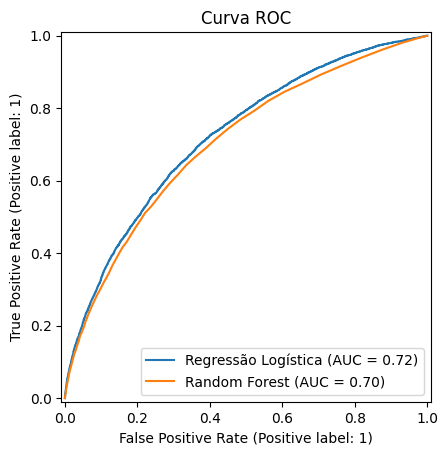

In [9]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

predsLR = modelLR.predict_proba(X_test_lr)[:, 1]
predsRF = modelRF.predict_proba(X_test_tree)[:, 1]

print(f"Taxa de inadimplência no teste: {y_test.mean():.2%}")
print('Regressão Logística - AUC: ', roc_auc_score(y_test, predsLR))
print('Random Forest - AUC: ', roc_auc_score(y_test, predsRF))

modelo_escolhido = modelLR
preds_modelo = predsLR
y_pred = (preds_modelo >= 0.5).astype(int)

print("\nRelatório de classificação - Regressão Logística")
print(classification_report(y_test, y_pred, digits=3))

print("Matriz de confusão - Regressão Logística")
print(confusion_matrix(y_test, y_pred))

RocCurveDisplay.from_predictions(y_test, predsLR, name="Regressão Logística")
RocCurveDisplay.from_predictions(y_test, predsRF, name="Random Forest", ax=plt.gca())
plt.title("Curva ROC")
plt.show()

# Explicabilidade dos modelos

Nesta etapa, vamos olhar quais variáveis mais pesam nos modelos. Isso ajuda a transformar a previsão em uma análise de crédito mais interpretável.

,feature,coeficiente_regressao_logistica,impacto_absoluto
6,EXT_SOURCE_3,-0.480468,0.480468
5,EXT_SOURCE_2,-0.456066,0.456066
4,EXT_SOURCE_1,-0.253013,0.253013
3,DAYS_EMPLOYED,0.168796,0.168796
7,dti,0.130847,0.130847
1,AMT_CREDIT,-0.074304,0.074304
0,AMT_INCOME_TOTAL,0.047818,0.047818
2,AMT_ANNUITY,0.041569,0.041569
8,credit_income_ratio,-0.014968,0.014968


,feature,importancia_random_forest
5,EXT_SOURCE_2,0.177380
6,EXT_SOURCE_3,0.151842
3,DAYS_EMPLOYED,0.118188
7,dti,0.107316
2,AMT_ANNUITY,0.106856
8,credit_income_ratio,0.102378
1,AMT_CREDIT,0.096684
4,EXT_SOURCE_1,0.079066
0,AMT_INCOME_TOTAL,0.060289


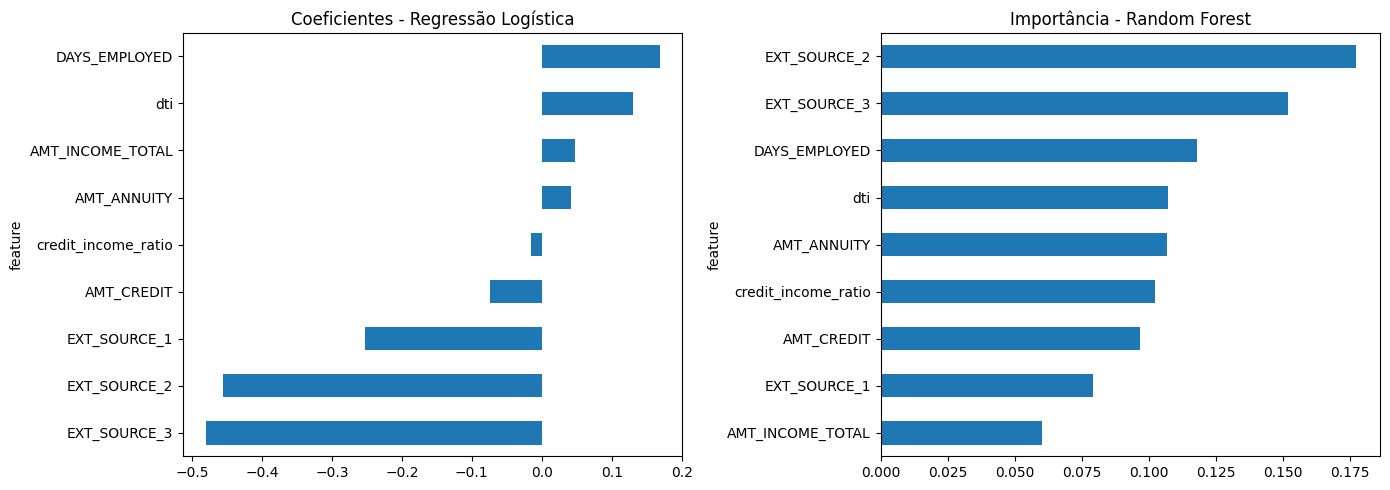

In [10]:
coeficientes_lr = pd.DataFrame({
    "feature": X.columns,
    "coeficiente_regressao_logistica": modelLR.coef_[0]
})
coeficientes_lr["impacto_absoluto"] = coeficientes_lr["coeficiente_regressao_logistica"].abs()
coeficientes_lr = coeficientes_lr.sort_values("impacto_absoluto", ascending=False)

importancias_rf = pd.DataFrame({
    "feature": X.columns,
    "importancia_random_forest": modelRF.feature_importances_
}).sort_values("importancia_random_forest", ascending=False)

principais_fatores_modelo = coeficientes_lr.head(5)["feature"].tolist()

display(coeficientes_lr)
display(importancias_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

coeficientes_lr.sort_values("coeficiente_regressao_logistica").plot.barh(
    x="feature",
    y="coeficiente_regressao_logistica",
    ax=axes[0],
    legend=False,
    title="Coeficientes - Regressão Logística"
)

importancias_rf.sort_values("importancia_random_forest").plot.barh(
    x="feature",
    y="importancia_random_forest",
    ax=axes[1],
    legend=False,
    title="Importância - Random Forest"
)

plt.tight_layout()
plt.show()

# Teste Cliente Real

In [11]:
def classificar_risco(prob):
    if prob < 0.10:
        return "Baixo risco"
    if prob < 0.20:
        return "Risco moderado"
    return "Alto risco"

cliente = X_test.iloc[[0]]
cliente_lr = preprocess_lr.transform(cliente)
prob_default = modelLR.predict_proba(cliente_lr)[0][1]
risco = classificar_risco(prob_default)

print(f"Probabilidade de inadimplência: {prob_default:.2%}")
print(f"Classificação: {risco}")
cliente

Probabilidade de inadimplência: 48.26%
Classificação: Alto risco


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,dti,credit_income_ratio
256571,157500.0,770292.0,30676.5,-105.0,NaN,0.594327,0.427657,0.194771,4.890743


In [12]:
def criar_prompt(cliente, prob, risco):
    dados_cliente = cliente.to_dict(orient="records")[0]
    return f"""
Você é um analista de crédito de um grande banco.

Dados do cliente:
{dados_cliente}

Probabilidade estimada de inadimplência: {prob:.2%}
Classificação preliminar do modelo: {risco}
Variáveis mais relevantes para o modelo: {principais_fatores_modelo}

Considere boas práticas de crédito, mas trate o modelo como apoio à decisão, não como decisão automática.

Responda:
- Classificação de risco
- Principais fatores observados nos dados
- Recomendação
- Justificativa profissional
- Cuidados ou informações adicionais que o banco deveria verificar
"""

In [13]:
import os
from getpass import getpass
from groq import Groq


def obter_groq_api_key():
    api_key = os.environ.get("GROQ_API_KEY")

    if not api_key:
        try:
            from google.colab import userdata
            api_key = userdata.get("API_Key_GROQ")
        except Exception:
            api_key = None

    if not api_key:
        api_key = getpass("Cole sua GROQ_API_KEY: ").strip()

    if not api_key:
        raise ValueError("GROQ_API_KEY não informada. Configure a chave da Groq para gerar a análise textual.")

    os.environ["GROQ_API_KEY"] = api_key
    return api_key


client = Groq(api_key=obter_groq_api_key())

prompt = criar_prompt(cliente, prob_default, risco)

try:
    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": "Você é um especialista em risco de crédito."},
            {"role": "user", "content": prompt}
        ],
        model="llama-3.3-70b-versatile",
        temperature=0.2
    )

    analise = response.choices[0].message.content
    print(analise)
except Exception as erro:
    print("Não foi possível gerar a análise com a Groq.")
    print(f"Tipo do erro: {type(erro).__name__}")
    print(f"Detalhe: {erro}")
    print("Verifique se a chave GROQ_API_KEY está correta e se o modelo configurado está disponível na sua conta.")

**Classificação de Risco:**
Com base nos dados fornecidos e considerando as boas práticas de crédito, classifico o risco deste cliente como **Alto Risco**. Essa classificação é apoiada pela probabilidade estimada de inadimplência de 48,26%, que é significativamente alta e indica um risco substancial de não pagamento.

**Principais Fatores Observados nos Dados:**
Os principais fatores que contribuem para essa classificação incluem:
- **EXT_SOURCE_3 e EXT_SOURCE_2:** Essas variáveis, que parecem ser scores de crédito externos, apresentam valores que podem indicar um histórico de crédito questionável ou inconsistente.
- **DAYS_EMPLOYED:** O valor negativo de -105 dias empregados sugere que o cliente pode estar desempregado ou ter uma situação de emprego instável, o que aumenta o risco de inadimplência.
- **dti (Relação Dívida-Renda):** A relação dívida-renda de 0,1947 indica que o cliente dedica uma parcela significativa de sua renda para pagamento de dívidas, o que pode limitar sua capac